GRAPH

05

인접 행렬 표현을 사용합니다.모든 정점 사이에 간선이 존재하는 완전 그래프는 간선의 수가 매우 많은 밀집 그래프입니다. 인접 행렬을 사용하면 임의의 두 정점 간의 간선 존재 여부를 $O(1)$의 시간 복잡도로 즉시 확인할 수 있습니다. 또한, 대부분의 칸이 간선 정보로 채워지기 때문에 메모리 낭비가 거의 없으며, 인접 리스트처럼 포인터를 저장하기 위한 추가적인 메모리 오버헤드도 발생하지 않아 효율적입니다.

06
인접 리스트 표현을 사용합니다. 간선이 아주 드물게 존재하는 희소 그래프에 인접 행렬을 사용하면, 대부분의 요소가 0으로 채워져 막대한 메모리가 낭비됩니다. 반면 인접 리스트는 존재하는 간선의 정보만을 저장하므로 메모리 공간을 매우 효율적으로 사용할 수 있습니다.


08 DFS(x)는 처음 시작하는 '정점 1'의 진출 차수(무방향 그래프일 경우
차수)만큼 호출됩니다.

DFS(v) 내부의 반복문은 정점 v에 인접한 모든 정점 x를 검사하고, x가 방문되지 않은 상태일 때만 DFS(x)를 재귀적으로 호출합니다. 정점 1에서 최초로 DFS가 시작될 때는 인접한 모든 정점이 아직 방문되지 않은 상태이므로, 정점 1과 연결된 간선의 수만큼 정확히 호출이 발생한다.

12
(1) 프림 알고리즘 임의의 정점에서 시작한다고 가정할 때, 트리에 인접한 간선 중 가중치가 가장 작은 간선을 차례대로 추가합니다.

가중치 1 간선 선택   
가중치 2 간선 선택   
가중치 3 간선 선택   
가중치 4 간선 선택   
가중치 5 간선 선택   
가중치 9 간선 선택   
가중치 8 간선 선택 (좌측 상단의 8)   
  
선택된 간선 가중치 순서: 1 → 2 → 3 → 4 → 5 → 9 → 8 (총합 32)   

12-(2)
크루스칼 알고리즘 모든 간선을 가중치 오름차순으로 정렬한 뒤, 사이클을 형성하지 않는 선에서 순서대로 추가합니다.  

오름차순 정렬: 1, 2, 3, 4, 5, 7, 8, 8, 8, 9, 10, 11, 12, 15   
1, 2, 3, 4, 5 가중치 간선 순차적 선택  
가중치 7 간선은 사이클을 형성하므로 제외   
가중치 8 간선 중 좌측 상단 간선 선택

가중치 9 간선 선택

선택된 간선 가중치 순서: 1 → 2 → 3 → 4 → 5 → 8 → 9 

16

TopologicalSort_with_Stack(Graph):
    Stack S = empty
    for each vertex v in Graph:
        visited[v] = false
    
    for each vertex v in Graph:
        if visited[v] == false:
            DFS(v, S)
            
    while S is not empty:
        print S.pop()

DFS(v, S):
    visited[v] = true
    for each neighbor u of v:
        if visited[u] == false:
            DFS(u, S)
    S.push(v)

가능한 위상 정렬 순서의 수: 총 42가지

17


In [9]:
def print_dijkstra_table(graph, start_node):
    # 그래프에 있는 모든 정점 리스트
    nodes = ['Q', 'A', 'B', 'C', 'D', 'E', 'F', 'G']
    
    # 거리 배열(d)을 무한대(inf)로 초기화, 시작 정점은 0
    distances = {node: float('inf') for node in nodes}
    distances[start_node] = 0
    
    # 방문 완료된 정점을 순서대로 담을 리스트 (집합 S)
    visited = []
    
    # 표 헤더 출력
    header = f"{'단계':<4} | {'S (방문 완료)':<22} | " + " | ".join([f"d({n})" for n in nodes])
    print(header)
    print("-" * len(header))
    
    # 초기 상태 출력
    def format_dist(d):
        return "∞" if d == float('inf') else str(d)
    
    init_dists = " | ".join([f"{format_dist(distances[n]):>4}" for n in nodes])
    print(f"{'초기':<4} | {'{ }':<22} | {init_dists}")
    
    step = 1
    while len(visited) < len(nodes):
        # 방문하지 않은 정점 중 가장 거리가 짧은 정점 찾기
        min_node = None
        min_dist = float('inf')
        for node in nodes:
            if node not in visited and distances[node] < min_dist:
                min_node = node
                min_dist = distances[node]
                
        if min_node is None: # 남은 정점에 도달할 수 없는 경우 종료
            break
            
        # 가장 거리가 짧은 정점을 방문 완료 처리
        visited.append(min_node)
        
        # 방금 방문한 정점(min_node)을 거쳐가는 경로가 더 짧은지 확인하고 거리 갱신
        for neighbor, weight in graph[min_node].items():
            if neighbor not in visited:
                new_dist = distances[min_node] + weight
                if new_dist < distances[neighbor]:
                    distances[neighbor] = new_dist
                    
        # 현재 단계의 결과 출력
        s_str = "{" + ", ".join(visited) + "}"
        dists_str = " | ".join([f"{format_dist(distances[n]):>4}" for n in nodes])
        print(f"{step:<4} | {s_str:<22} | {dists_str}")
        step += 1

# 17번 문제의 그래프 정보 (인접 리스트 형태)
# 각 정점에서 갈 수 있는 이웃 정점과 그 간선의 가중치
graph_17 = {
    'Q': {'A': 10, 'C': 7, 'E': 4},
    'A': {'B': 8},
    'B': {'D': 12},
    'C': {'A': 2, 'B': 8},
    'D': {'G': 4},
    'E': {'C': 2, 'F': 8, 'G': 20},
    'F': {'C': 12, 'D': 7, 'G': 3},
    'G': {}
}

# 함수 실행 (시작 정점 'Q')
print_dijkstra_table(graph_17, 'Q')

단계   | S (방문 완료)              | d(Q) | d(A) | d(B) | d(C) | d(D) | d(E) | d(F) | d(G)
-------------------------------------------------------------------------------------
초기   | { }                    |    0 |    ∞ |    ∞ |    ∞ |    ∞ |    ∞ |    ∞ |    ∞
1    | {Q}                    |    0 |   10 |    ∞ |    7 |    ∞ |    4 |    ∞ |    ∞
2    | {Q, E}                 |    0 |   10 |    ∞ |    6 |    ∞ |    4 |   12 |   24
3    | {Q, E, C}              |    0 |    8 |   14 |    6 |    ∞ |    4 |   12 |   24
4    | {Q, E, C, A}           |    0 |    8 |   14 |    6 |    ∞ |    4 |   12 |   24
5    | {Q, E, C, A, F}        |    0 |    8 |   14 |    6 |   19 |    4 |   12 |   15
6    | {Q, E, C, A, F, B}     |    0 |    8 |   14 |    6 |   19 |    4 |   12 |   15
7    | {Q, E, C, A, F, B, G}  |    0 |    8 |   14 |    6 |   19 |    4 |   12 |   15
8    | {Q, E, C, A, F, B, G, D} |    0 |    8 |   14 |    6 |   19 |    4 |   12 |   15


18


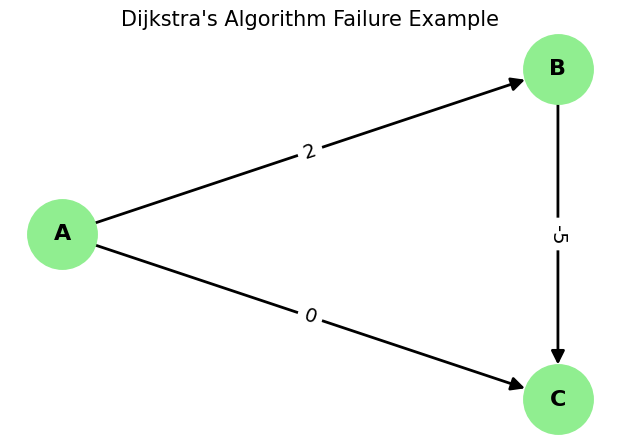

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. 방향 그래프(Directed Graph) 객체 생성
G = nx.DiGraph()

# 2. 정점(노드)과 간선(에지), 가중치 추가
# A -> B (가중치 2), A -> C (가중치 0), B -> C (가중치 -5)
G.add_edge('A', 'B', weight=2)
G.add_edge('A', 'C', weight=0)
G.add_edge('B', 'C', weight=-5)

# 3. 그래프를 예쁘게 출력하기 위한 정점 위치 설정 (삼각형 구도)
pos = {'A': (0, 0.5), 'B': (1, 1), 'C': (1, 0)}

# 4. 그림 크기 설정
plt.figure(figsize=(6, 4))

# 5. 노드 및 기본 간선 그리기
nx.draw(G, pos, with_labels=True, node_color='lightgreen', 
        node_size=2500, font_size=16, font_weight='bold', 
        arrowsize=20, width=2)

# 6. 간선의 가중치(Weight) 라벨 그리기
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=14)

# 7. 제목 추가 및 출력
plt.title("Dijkstra's Algorithm Failure Example", fontsize=15)
plt.axis('off') # 배경 축 숨기기
plt.show()

22
그래프 내에 가중치의 합이 음수인 사이클이 존재하는 경우입니다.

SORTING

05-(1)
초기 상태: [12, 70, 30, 20, 55, 25]

1단계: 전체 중 최솟값 12 선택. 이미 첫 번째 위치에 있으므로 교환 없음.

결과: [12] | 70, 30, 20, 55, 25 

2단계: 나머지 중 최솟값 20 선택. 두 번째 자리의 70과 교환.

결과: [12, 20] | 30, 70, 55, 25

3단계: 나머지 중 최솟값 25 선택. 세 번째 자리의 30과 교환.

결과: [12, 20, 25] | 70, 55, 30

4단계: 나머지 중 최솟값 30 선택. 네 번째 자리의 70과 교환.

결과: [12, 20, 25, 30] | 55, 70

5단계: 나머지 중 최솟값 55 선택. 제자리에 있으므로 교환 없음.

결과: [12, 20, 25, 30, 55] | 70 

최종 결과: [12, 20, 25, 30, 55, 70]

05-(2)
초기 상태: 12, 70, 30, 20, 55, 25

Pass 1: (가장 큰 수 70이 맨 끝으로 이동)

12, 70 비교 (유지)

70, 30 비교 (교환) -> 12, 30, 70, 20, 55, 25

70, 20 비교 (교환) -> 12, 30, 20, 70, 55, 25

70, 55 비교 (교환) -> 12, 30, 20, 55, 70, 25

70, 25 비교 (교환) -> 12, 30, 20, 55, 25, [70]

Pass 2: (두 번째로 큰 수 55가 끝에서 두 번째로 이동)

12, 30 비교 (유지)

30, 20 비교 (교환) -> 12, 20, 30, 55, 25, [70]

30, 55 비교 (유지)

55, 25 비교 (교환) -> 12, 20, 30, 25, [55, 70]

Pass 3: (세 번째로 큰 수 30이 이동)

12, 20 비교 (유지)

20, 30 비교 (유지)

30, 25 비교 (교환) -> 12, 20, 25, [30, 55, 70]

Pass 4 & 5: 더 이상 교환이 발생하지 않아 정렬이 완료됨.

최종 결과: [12, 20, 25, 30, 55, 70]

05-(3)
초기 상태: [12] | 70, 30, 20, 55, 25 
1단계: 70 삽입. 12 뒤에 위치.

결과: [12, 70] | 30, 20, 55, 25

2단계: 30 삽입. 12와 70 사이에 위치.

결과: [12, 30, 70] | 20, 55, 25

3단계: 20 삽입. 12와 30 사이에 위치.

결과: [12, 20, 30, 70] | 55, 25

4단계: 55 삽입. 30과 70 사이에 위치.

결과: [12, 20, 30, 55, 70] | 25

5단계: 25 삽입. 20과 30 사이에 위치.

결과: [12, 20, 25, 30, 55, 70]

06-(1)
분할(Divide) 과정:

1차: [12, 70, 30, 20], [55, 25, 40, 50]

2차: [12, 70], [30, 20], [55, 25], [40, 50]

3차: [12], [70], [30], [20], [55], [25], [40], [50]

병합 과정:

1차 합병 (2개씩): [12, 70], [20, 30], [25, 55], [40, 50]

2차 합병 (4개씩): [12, 20, 30, 70], [25, 40, 50, 55]

3차 합병 (8개 전체): [12, 20, 25, 30, 40, 50, 55, 70]

06-(2)
1단계: 최대 힙 구성하기 

초기 트리 형태 (배열 순서대로):
12(루트) - 70, 30 - 20, 55, 25, 40 - 50

가장 마지막 부모 노드부터 자식과 비교하며 힙 속성 유지:

최종 배열: [70, 55, 40, 50, 12, 25, 30, 20]

2단계: 최댓값 추출 및 정렬 (루트를 맨 끝 원소와 교환 후 Heapify)

1회: 루트 70 ↔ 끝 20 교환 [20, 55, 40, 50, 12, 25, 30 | 70] -> Heapify -> [55, 50, 40, 20, 12, 25, 30 | 70]

2회: 루트 55 ↔ 끝 30 교환 [30, 50, 40, 20, 12, 25 | 55, 70] -> Heapify -> [50, 30, 40, 20, 12, 25 | 55, 70]

3회: 루트 50 ↔ 끝 25 교환 [25, 30, 40, 20, 12 | 50, 55, 70] -> Heapify -> [40, 30, 25, 20, 12 | 50, 55, 70]

4회: 루트 40 ↔ 끝 12 교환 [12, 30, 25, 20 | 40, 50, 55, 70] -> Heapify -> [30, 20, 25, 12 | 40, 50, 55, 70]

5회: 루트 30 ↔ 끝 12 교환 [12, 20, 25 | 30, 40, 50, 55, 70] -> Heapify -> [25, 20, 12 | 30, 40, 50, 55, 70]

6회: 루트 25 ↔ 끝 12 교환 [12, 20 | 25, 30, 40, 50, 55, 70] -> Heapify -> [20, 12 | 25, 30, 40, 50, 55, 70]

7회: 루트 20 ↔ 끝 12 교환 [12 | 20, 25, 30, 40, 50, 55, 70]

최종 결과: [12, 20, 25, 30, 40, 50, 55, 70]

06-(3)
초기 상태: [12, 70, 30, 20, 55, 25, 40, 50]

1단계 (Pivot = 12):

비교: 12보다 작은 값 없음, 나머지 모두 큼.

분할: [ ] + 12 + [70, 30, 20, 55, 25, 40, 50]

(12는 정렬 위치 확정)

2단계 (오른쪽 부분집합의 Pivot = 70):

부분집합: [70, 30, 20, 55, 25, 40, 50]

분할: [30, 20, 55, 25, 40, 50] + 70 + [ ]

(70 정렬 위치 확정)

3단계 (왼쪽 부분집합의 Pivot = 30):

부분집합: [30, 20, 55, 25, 40, 50]

분할: [20, 25] + 30 + [55, 40, 50]

(30 정렬 위치 확정)

4단계 (하위 집합들 정렬):

[20, 25] 묶음: Pivot 20 -> [ ] + 20 + [25] -> 완료

[55, 40, 50] 묶음: Pivot 55 -> [40, 50] + 55 + [ ]

[40, 50] 묶음: Pivot 40 -> [ ] + 40 + [50] -> 완료

최종 병합 결과: [12, 20, 25, 30, 40, 50, 55, 70]